# 3. Establish the simplest possible baseline


In [1]:
import pandas as pd

DATA_DIR = "../data/complete_dataset.csv"

In [3]:
df_raw = pd.read_csv(DATA_DIR)
df_raw.head()

,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y
1,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N
2,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N
3,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N
4,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N


In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             2106 non-null   str    
 1   demand           2106 non-null   float64
 2   RRP              2106 non-null   float64
 3   demand_pos_RRP   2106 non-null   float64
 4   RRP_positive     2106 non-null   float64
 5   demand_neg_RRP   2106 non-null   float64
 6   RRP_negative     2106 non-null   float64
 7   frac_at_neg_RRP  2106 non-null   float64
 8   min_temperature  2106 non-null   float64
 9   max_temperature  2106 non-null   float64
 10  solar_exposure   2105 non-null   float64
 11  rainfall         2103 non-null   float64
 12  school_day       2106 non-null   str    
 13  holiday          2106 non-null   str    
dtypes: float64(11), str(3)
memory usage: 230.5 KB


In [7]:
print(df_raw['school_day'].unique())
print(df_raw['holiday'].unique())

<StringArray>
['N', 'Y']
Length: 2, dtype: str
<StringArray>
['Y', 'N']
Length: 2, dtype: str


In [4]:
df_clean = df_raw.copy()

df_clean['school_day'] =df_raw['school_day'].map({'Y': 1, 'N': 0})
df_clean["holiday"] = df_raw["holiday"].map({"Y": 1, "N": 0})

df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             2106 non-null   datetime64[us]
 1   demand           2106 non-null   float64       
 2   RRP              2106 non-null   float64       
 3   demand_pos_RRP   2106 non-null   float64       
 4   RRP_positive     2106 non-null   float64       
 5   demand_neg_RRP   2106 non-null   float64       
 6   RRP_negative     2106 non-null   float64       
 7   frac_at_neg_RRP  2106 non-null   float64       
 8   min_temperature  2106 non-null   float64       
 9   max_temperature  2106 non-null   float64       
 10  solar_exposure   2105 non-null   float64       
 11  rainfall         2103 non-null   float64       
 12  school_day       2106 non-null   int64         
 13  holiday          2106 non-null   int64         
dtypes: datetime64[us](1), float64(11), int64(2)
memory 

In [4]:
df_clean.head(3)

,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,2015-01-01,99635.03,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,0,1
1,2015-01-02,129606.01,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,0,0
2,2015-01-03,142300.54,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,0,0


In [37]:
df_clean['date'].dtype

datetime64[us, UTC]

In [5]:
df_clean.to_csv("../data/cleaned_data.csv")


In [5]:
df_clean = df_clean.iloc[:, 0:2]
df_clean.head()

,date,demand
0,2015-01-01,99635.030
1,2015-01-02,129606.010
2,2015-01-03,142300.540
3,2015-01-04,104330.715
4,2015-01-05,118132.200


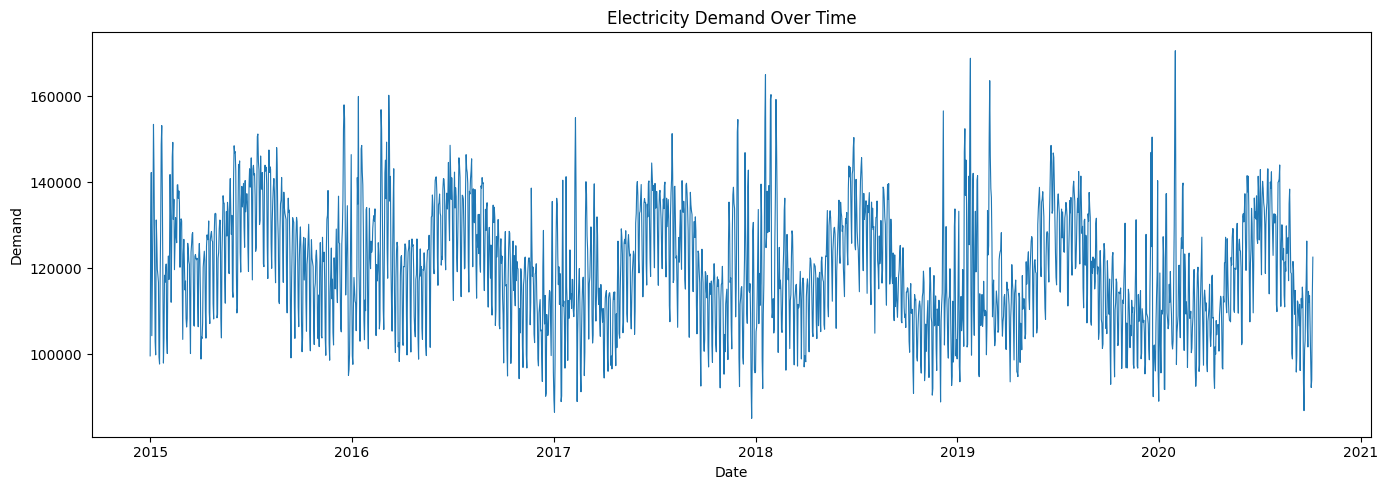

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_clean['date'], df_clean['demand'], linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Demand')
ax.set_title('Electricity Demand Over Time')
fig.tight_layout()
plt.show()

from the graph the trend is quite predictive. it's like wave up n down trend.
For a Naive approach i was thinking rolling avg but i think that would smooth the data too much and turn to like a straight line.

SO i decided to first check the seasonality pattern

In [18]:
print(df_clean["date"].dtype)


datetime64[us, UTC]


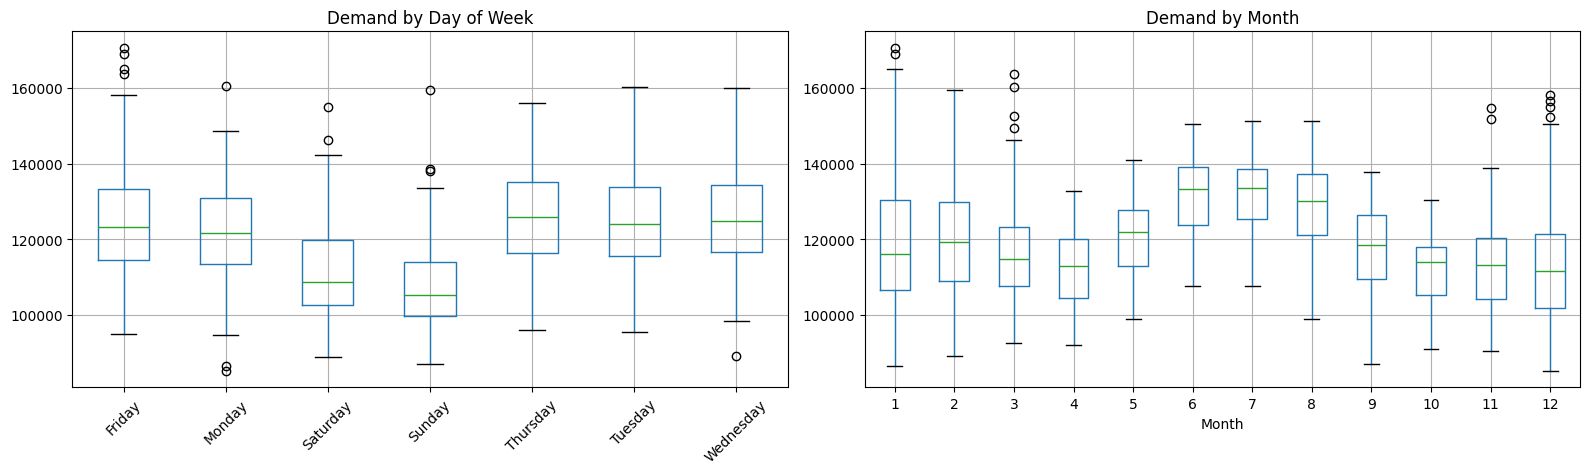

In [21]:
df_clean['day_of_week'] = df_clean['date'].dt.day_name()
df_clean['month'] = df_clean['date'].dt.month

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_clean.boxplot(column='demand', by='day_of_week', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_title('Demand by Day of Week')
axes[0].set_xlabel('')

df_clean.boxplot(column='demand', by='month', ax=axes[1])
axes[1].set_title('Demand by Month')
axes[1].set_xlabel('Month')

plt.suptitle('')
fig.tight_layout()
plt.show()

### My insight: Boxplot (day of week / month)

- The middle line in each box is the median demand for that category. If the median shifts up/down across categories, that category matters for demand.
- Weekday boxes sit higher than weekend boxes → demand drops on Saturday/Sunday. Makes sense, offices and factories aren't running.
- The month boxes also shift up and down across the year → some months use noticeably more electricity than others, probably heating/cooling load.
- Takeaway: both "day of week" and "month" look like they carry real information about demand, not just noise.

Boxplots tell us *if* there's a level shift by weekday/month. To confirm periodicity more rigorously, check the autocorrelation function (ACF) — a spike at lag 7 confirms a weekly cycle.


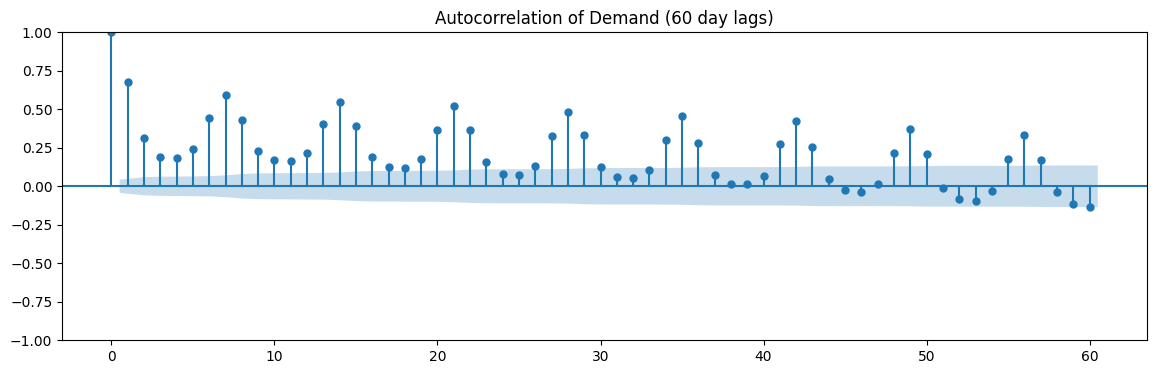

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(df_clean['demand'], lags=60, ax=ax)
ax.set_title('Autocorrelation of Demand (60 day lags)')
plt.show()

### My insight: ACF plot

- Each bar = how correlated today's demand is with demand `lag` days ago. Bars sticking out past the shaded blue cone are real correlation, not noise.
- I counted the bars and there's a clear spike at lag 7, then again at lag 14, 21, 28... every multiple of 7.
- This confirms a strong **weekly cycle**: demand today looks a lot like demand on the same weekday last week, and the week before that, and so on.
- This matches the boxplot finding, but is stronger evidence because it's measuring the actual correlation instead of just visual spread.
- Decision: since the wave pattern repeats every 7 days, my naive baseline should predict tomorrow using demand from the same weekday last week, not just yesterday's value, and not a smoothed rolling average.

## Naive baseline — seasonal naive (lag-7)

Prediction rule: `demand(t+1) = demand(t+1-7)` — tomorrow's demand equals demand from the same weekday, one week ago.

We'll also compute plain persistence (`demand(t+1) = demand(t)`) alongside it for comparison, since that's the "simplest" naive baseline the TODO asks for — this shows whether respecting weekly seasonality actually helps.

In [23]:
import numpy as np

df_naive = df_clean[['date', 'demand']].copy()

# persistence: predict tomorrow = today
df_naive['pred_persistence'] = df_naive['demand'].shift(1)

# seasonal naive: predict tomorrow = same weekday last week
df_naive['pred_seasonal'] = df_naive['demand'].shift(7)

df_naive = df_naive.dropna().reset_index(drop=True)

df_naive.head(10)

,date,demand,pred_persistence,pred_seasonal
0,2015-01-08 00:00:00+00:00,142015.655,153514.820,99635.030
1,2015-01-09 00:00:00+00:00,121801.155,142015.655,129606.010
2,2015-01-10 00:00:00+00:00,103043.660,121801.155,142300.540
3,2015-01-11 00:00:00+00:00,99865.755,103043.660,104330.715
4,2015-01-12 00:00:00+00:00,131261.125,99865.755,118132.200
5,2015-01-13 00:00:00+00:00,126527.360,131261.125,130672.485
6,2015-01-14 00:00:00+00:00,119741.620,126527.360,153514.820
7,2015-01-15 00:00:00+00:00,118411.220,119741.620,142015.655
8,2015-01-16 00:00:00+00:00,116690.765,118411.220,121801.155
9,2015-01-17 00:00:00+00:00,99371.310,116690.765,103043.660


In [24]:
df_naive.tail(10)

,date,demand,pred_persistence,pred_seasonal
2089,2020-09-27 00:00:00+00:00,101703.490,106694.965,86891.230
2090,2020-09-28 00:00:00+00:00,114651.140,101703.490,100977.950
2091,2020-09-29 00:00:00+00:00,112076.460,114651.140,103200.640
2092,2020-09-30 00:00:00+00:00,113620.210,112076.460,112412.445
2093,2020-10-01 00:00:00+00:00,106641.790,113620.210,117535.715
2094,2020-10-02 00:00:00+00:00,99585.835,106641.790,126354.680
2095,2020-10-03 00:00:00+00:00,92277.025,99585.835,106694.965
2096,2020-10-04 00:00:00+00:00,94081.565,92277.025,101703.490
2097,2020-10-05 00:00:00+00:00,113610.030,94081.565,114651.140
2098,2020-10-06 00:00:00+00:00,122607.560,113610.030,112076.460


In [ ]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

results = {
    'Persistence (t-1)': {
        'MAE': mae(df_naive['demand'], df_naive['pred_persistence']),
        'RMSE': rmse(df_naive['demand'], df_naive['pred_persistence']),
    },
    'Seasonal naive (t-7)': {
        'MAE': mae(df_naive['demand'], df_naive['pred_seasonal']),
        'RMSE': rmse(df_naive['demand'], df_naive['pred_seasonal']),
    },
}

pd.DataFrame(results).T

,MAE,RMSE
Persistence (t-1),8132.591096,10951.137568
Seasonal naive (t-7),8670.743152,12328.723363


### My insight — Baseline results

| Model | MAE | RMSE |
|---|---:|---:|
| Persistence (t-1) | 8,132.59 | 10,951.14 |
| Seasonal naive (t-7) | 8,670.74 | 12,328.72 |

- Persistence (predict tomorrow = today) beats seasonal naive (predict tomorrow = same weekday last week) on both MAE and RMSE.
- This doesn't contradict the ACF finding — lag-7 was a *real, significant* correlation, just not as strong as lag-1. Day-to-day demand is stickier (weather/routine carries over one day) than week-to-week demand (7 days is enough time for conditions to drift).
- Decision: **Persistence (t-1) is my baseline to beat.** MAE ≈ 8,132, RMSE ≈ 10,951. Any RNN/LSTM/GRU/Transformer needs to clearly beat these numbers to justify its added complexity.
- Open question to keep in mind: a model that uses *both* recent value and weekly position (e.g. a 7+ day window) might beat persistence by combining both signals — that's exactly what the sequence models should be able to test.

In [29]:
results

{'Persistence (t-1)': {'MAE': np.float64(8132.591095759884),
  'RMSE': np.float64(10951.13756817085)},
 'Seasonal naive (t-7)': {'MAE': np.float64(8670.743151500714),
  'RMSE': np.float64(12328.72336296143)}}